In [1]:
# DATA MANIPUALTION 
import pandas as pd
import numpy as np
import os 

# DATA VIZUALIZATION 
import matplotlib.pyplot as plt
import seaborn as sns

# MACHINE LEARNING & PREPROCESSING 
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from pathlib import Path
import xgboost as xgb




In [2]:
DATA_PATH = Path('ufc.csv')  

'''
There are several advantages to using Path:
1. Modern and clean
2. Error-free
3. Easy to debug
4. Close to production

'''

if not DATA_PATH.exists():
    raise FileNotFoundError(f"{DATA_PATH} not found")

df = pd.read_csv('ufc.csv')
print(f'Loaded data shape: {df.shape}')


Loaded data shape: (7417, 18)


In [3]:
# Initial data inspection 
print('--- Dataset Shape ---')
print(df.shape)

# Display First 5 Rows 
print('\n --- First 5 Rows ---')
display(df.head())

# Data Information 
print('\n --- Data Information ---')
print(df.info())

--- Dataset Shape ---
(7417, 18)

 --- First 5 Rows ---


,Location,Fighter 1,Fighter 2,Fighter_1_KD,Fighter_2_KD,Fighter_1_STR,Fighter_2_STR,Fighter_1_TD,Fighter_2_TD,Fighter_1_SUB,Fighter_2_SUB,Weight_Class,Method,Round,Time,Event Name,Date,Winner
0,"Austin, Texas, USA",Arman Tsarukyan,Beneil Dariush,1.0,0.0,8.0,2.0,0.0,0.0,0.0,0.0,Lightweight,KO/TKO Punch,1.0,1:04,UFC Fight Night,2-Dec-23,Arman Tsarukyan
1,"Austin, Texas, USA",Jalin Turner,Bobby Green,1.0,0.0,33.0,15.0,0.0,0.0,0.0,0.0,Lightweight,KO/TKO Punches,1.0,2:49,UFC Fight Night,2-Dec-23,Jalin Turner
2,"Austin, Texas, USA",Deiveson Figueiredo,Rob Font,0.0,0.0,45.0,46.0,4.0,0.0,0.0,0.0,Bantamweight,U-DEC,3.0,5:00,UFC Fight Night,2-Dec-23,Deiveson Figueiredo
3,"Austin, Texas, USA",Sean Brady,Kelvin Gastelum,0.0,0.0,14.0,18.0,5.0,0.0,3.0,0.0,Welterweight,SUB Kimura,3.0,1:43,UFC Fight Night,2-Dec-23,Sean Brady
4,"Austin, Texas, USA",Joaquim Silva,Clay Guida,0.0,0.0,46.0,43.0,2.0,2.0,2.0,0.0,Lightweight,U-DEC,3.0,5:00,UFC Fight Night,2-Dec-23,Joaquim Silva



 --- Data Information ---
<class 'pandas.DataFrame'>
RangeIndex: 7417 entries, 0 to 7416
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Location       7417 non-null   str    
 1   Fighter 1      7417 non-null   str    
 2   Fighter 2      7413 non-null   str    
 3   Fighter_1_KD   7413 non-null   float64
 4   Fighter_2_KD   7413 non-null   float64
 5   Fighter_1_STR  7413 non-null   float64
 6   Fighter_2_STR  7413 non-null   float64
 7   Fighter_1_TD   7413 non-null   float64
 8   Fighter_2_TD   7413 non-null   float64
 9   Fighter_1_SUB  7413 non-null   float64
 10  Fighter_2_SUB  7413 non-null   float64
 11  Weight_Class   7413 non-null   str    
 12  Method         7413 non-null   str    
 13  Round          7413 non-null   float64
 14  Time           7413 non-null   str    
 15  Event Name     7413 non-null   str    
 16  Date           7412 non-null   str    
 17  Winner         7414 non-null   str  

In [4]:
# To put the raw data into data/raw through os
output_folder = 'data/raw'
os.makedirs(output_folder, exist_ok = True)
output_path = os.path.join(output_folder, 'raw_dataset.csv')

df.to_csv(output_path, index=False)  # To save the raw dataset into the data/raw 
print(f'Raw dataset saved to: {output_path}')

Raw dataset saved to: data/raw/raw_dataset.csv


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7417 entries, 0 to 7416
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Location       7417 non-null   str    
 1   Fighter 1      7417 non-null   str    
 2   Fighter 2      7413 non-null   str    
 3   Fighter_1_KD   7413 non-null   float64
 4   Fighter_2_KD   7413 non-null   float64
 5   Fighter_1_STR  7413 non-null   float64
 6   Fighter_2_STR  7413 non-null   float64
 7   Fighter_1_TD   7413 non-null   float64
 8   Fighter_2_TD   7413 non-null   float64
 9   Fighter_1_SUB  7413 non-null   float64
 10  Fighter_2_SUB  7413 non-null   float64
 11  Weight_Class   7413 non-null   str    
 12  Method         7413 non-null   str    
 13  Round          7413 non-null   float64
 14  Time           7413 non-null   str    
 15  Event Name     7413 non-null   str    
 16  Date           7412 non-null   str    
 17  Winner         7414 non-null   str    
dtypes: float64(9), str(

In [6]:
# Feature Enineering
df['Date'] = pd.to_datetime(df['Date'])

/var/folders/j4/qzhh77r553z1scwnh3mxkx200000gn/T/ipykernel_12345/2826617988.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7417 entries, 0 to 7416
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Location       7417 non-null   str           
 1   Fighter 1      7417 non-null   str           
 2   Fighter 2      7413 non-null   str           
 3   Fighter_1_KD   7413 non-null   float64       
 4   Fighter_2_KD   7413 non-null   float64       
 5   Fighter_1_STR  7413 non-null   float64       
 6   Fighter_2_STR  7413 non-null   float64       
 7   Fighter_1_TD   7413 non-null   float64       
 8   Fighter_2_TD   7413 non-null   float64       
 9   Fighter_1_SUB  7413 non-null   float64       
 10  Fighter_2_SUB  7413 non-null   float64       
 11  Weight_Class   7413 non-null   str           
 12  Method         7413 non-null   str           
 13  Round          7413 non-null   float64       
 14  Time           7413 non-null   str           
 15  Event Name     7413 non-null   s

In [8]:
# DATA PREPROCESSING 

class DataPreprocessing:
    def __init__(self, df):
        self.df = df 
    
    # Handle Missing Values
    def fill_miss_vals(self):
        for col in self.df.columns:
            if self.df[col].isnull().any():
                
                if self.df[col].dtype == 'str':
                    self.df[col] = self.df[col].fillna(self.df[col].mode()[0], inplace=True)
                
                elif self.df[col].dtype == 'datetime64[ns]':
                     self.df[col] = self.df[col].fillna(self.df[col].median(), inplace=True)
                
                else:
                    self.df[col] = self.df[col].fillna(self.df[col].mean(), inplace=True)
                    
        return self
    
    # Encoding the columns from categorical to numerical 
    def encoding(self):
        le = LabelEncoder()
        cat_cols = self.df.select_dtypes(include=['str']).columns

        for col in cat_cols:
            self.df[col] = self.df[col].fillna(self.df[col].mode()[0], inplace=True)
            self.df[col] = le.fit_transform(self.df[col])
        return self
    
    # Scaling is not needed here, but included as a best practice.
    def scaling(self):
        scaler = MinMaxScaler()
        num_col = self.df.select_dtypes(
            include=['float64']
            ).columns.drop('Winner')
        self.df[num_col] = scaler.fit_transform(self.df[num_col])
        return self
    
processor = DataPreprocessing(df)
df_ready = (
    processor
    .fill_miss_vals()
    .df
)
# Dsiplaying the df_ready first 5 rows after Data Preprocessing 
print(f'---Data Preprocessing: ', df_ready.shape)
    

        

---Data Preprocessing:  (7417, 18)


/var/folders/j4/qzhh77r553z1scwnh3mxkx200000gn/T/ipykernel_12345/3797406216.py:13: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  self.df[col] = self.df[col].fillna(self.df[col].mode()[0], inplace=True)
/var/folders/j4/qzhh77r553z1scwnh3mxkx200000gn/T/ipykernel_12345/3797406216.py:19: ChainedAssignmentError: A value is being set on a 

In [9]:
df_ready.isnull().sum()

Location         0
Fighter 1        0
Fighter 2        0
Fighter_1_KD     0
Fighter_2_KD     0
Fighter_1_STR    0
Fighter_2_STR    0
Fighter_1_TD     0
Fighter_2_TD     0
Fighter_1_SUB    0
Fighter_2_SUB    0
Weight_Class     0
Method           0
Round            0
Time             0
Event Name       0
Date             0
Winner           0
dtype: int64

In [10]:
# Feature engineering: creating new variables from existing columns
# to capture additional patterns and relationships in the data

df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day

In [11]:
# Dropping the Date column 
df.drop('Date', axis=1, inplace=True)


In [12]:

df_ready = (
    processor
    .encoding()
    .df
)

/var/folders/j4/qzhh77r553z1scwnh3mxkx200000gn/T/ipykernel_12345/3797406216.py:29: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  self.df[col] = self.df[col].fillna(self.df[col].mode()[0], inplace=True)
/var/folders/j4/qzhh77r553z1scwnh3mxkx200000gn/T/ipykernel_12345/3797406216.py:29: ChainedAssignmentError: A value is being set on a 

In [13]:
df_ready.info()

<class 'pandas.DataFrame'>
RangeIndex: 7417 entries, 0 to 7416
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Location       7417 non-null   int64  
 1   Fighter 1      7417 non-null   int64  
 2   Fighter 2      7417 non-null   int64  
 3   Fighter_1_KD   7417 non-null   float64
 4   Fighter_2_KD   7417 non-null   float64
 5   Fighter_1_STR  7417 non-null   float64
 6   Fighter_2_STR  7417 non-null   float64
 7   Fighter_1_TD   7417 non-null   float64
 8   Fighter_2_TD   7417 non-null   float64
 9   Fighter_1_SUB  7417 non-null   float64
 10  Fighter_2_SUB  7417 non-null   float64
 11  Weight_Class   7417 non-null   int64  
 12  Method         7417 non-null   int64  
 13  Round          7417 non-null   float64
 14  Time           7417 non-null   int64  
 15  Event Name     7417 non-null   int64  
 16  Winner         7417 non-null   int64  
 17  year           7417 non-null   int32  
 18  month          7417

In [14]:
# Here we can see memory usage is sharply at 1.0 MB
# We can apply for klib as to eliminate the duplicated elements, standardize the columns, 
# and decrease the memory usage.
import klib 

klib.missingval_plot(df_ready)
df_ready =klib.data_cleaning(df_ready, drop_duplicates=True)   # Reduced memory by at least: (-56.48%)

No missing values found in the dataset.
Shape of cleaned data: (7417, 20) - Remaining NAs: 0


Dropped rows: 0
     of which 0 duplicates. (Rows (first 150 shown): [])

Dropped columns: 0
     of which 0 single valued.     Columns: []
Dropped missing values: 0
Reduced memory by at least: 0.61 MB (-58.1%)



In [15]:
df_ready.info()

<class 'pandas.DataFrame'>
RangeIndex: 7417 entries, 0 to 7416
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   location       7417 non-null   int16  
 1   fighter_1      7417 non-null   int16  
 2   fighter_2      7417 non-null   int16  
 3   fighter_1_kd   7417 non-null   float32
 4   fighter_2_kd   7417 non-null   float32
 5   fighter_1_str  7417 non-null   float32
 6   fighter_2_str  7417 non-null   float32
 7   fighter_1_td   7417 non-null   float32
 8   fighter_2_td   7417 non-null   float32
 9   fighter_1_sub  7417 non-null   float32
 10  fighter_2_sub  7417 non-null   float32
 11  weight_class   7417 non-null   int8   
 12  method         7417 non-null   int8   
 13  round          7417 non-null   float32
 14  time           7417 non-null   int16  
 15  event_name     7417 non-null   int16  
 16  winner         7417 non-null   int16  
 17  year           7417 non-null   int32  
 18  month          7417

In [16]:
# To put the preprocessed data into data/preprocessed through os
output_folder = 'data/preprocessed'
os.makedirs(output_folder, exist_ok = True)
output_path = os.path.join(output_folder, 'preprocessed_dataset.csv')

df.to_csv(output_path, index=False)  # To save the preprocessed dataset into the data/preprocessed
print(f'Preprocessed dataset saved to: {output_path}')

Preprocessed dataset saved to: data/preprocessed/preprocessed_dataset.csv


In [17]:
df = df_ready

In [18]:
# Transform Features
num_cols = df.select_dtypes(include=np.number)
skewness = num_cols.skew()


# Log Transformation skewness >= 0.5
log_transformation = skewness[(skewness>=0.5)].index.tolist()
print(f'The columns of the log transformation: ', log_transformation)


The columns of the log transformation:  ['fighter_1_kd', 'fighter_2_kd', 'fighter_1_str', 'fighter_2_str', 'fighter_1_td', 'fighter_2_td', 'fighter_1_sub', 'fighter_2_sub']


In [19]:
# Applying for Log Transformation above columns
cols = ['fighter_1_kd', 
        'fighter_2_kd', 
        'fighter_1_str', 
        'fighter_2_str', 
        'fighter_1_td', 
        'fighter_2_td', 
        'fighter_1_sub', 
        'fighter_2_sub']

for col in cols:
    df[col + '_log'] = np.log1p(df[col])

df = df.drop(cols, axis=1)

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7417 entries, 0 to 7416
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   location           7417 non-null   int16  
 1   fighter_1          7417 non-null   int16  
 2   fighter_2          7417 non-null   int16  
 3   weight_class       7417 non-null   int8   
 4   method             7417 non-null   int8   
 5   round              7417 non-null   float32
 6   time               7417 non-null   int16  
 7   event_name         7417 non-null   int16  
 8   winner             7417 non-null   int16  
 9   year               7417 non-null   int32  
 10  month              7417 non-null   int32  
 11  day                7417 non-null   int32  
 12  fighter_1_kd_log   7417 non-null   float32
 13  fighter_2_kd_log   7417 non-null   float32
 14  fighter_1_str_log  7417 non-null   float32
 15  fighter_2_str_log  7417 non-null   float32
 16  fighter_1_td_log   7417 non-null   

In [21]:
# Transform Features
num_cols = df.select_dtypes(include=np.number)
skewness = num_cols.skew()
print(skewness)

location            -0.028759
fighter_1            0.031503
fighter_2            0.007489
weight_class         0.225194
method              -0.104367
round                0.161357
time                -0.896618
event_name          -0.949043
winner               0.028370
year                -0.980916
month               -0.051765
day                  0.058813
fighter_1_kd_log     1.117126
fighter_2_kd_log     4.054119
fighter_1_str_log   -0.906169
fighter_2_str_log   -0.689164
fighter_1_td_log     0.601925
fighter_2_td_log     1.243655
fighter_1_sub_log    1.246575
fighter_2_sub_log    2.438095
dtype: float64


In [22]:
# FUTURE SELECTION

# Determine Correlation Matrices
corr_matrix = df.corr().abs()
# To create a triangle matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)) # 
# Identifying columns to be removed 
to_drop = [col for col in upper.columns if any (upper[col] > 0.75)]
# Dropping columns
df_filtered = df.drop(columns = to_drop)

print(f'\nOriginal Shape: ', df.shape)
print(f'Shape after dropping correlated features: ', df_filtered.shape)


Original Shape:  (7417, 20)
Shape after dropping correlated features:  (7417, 18)


In [23]:
# Finding high correlation pairs 
high_corr_pairs = []

for col in upper.columns:
    for row in upper.index:
        if upper.loc[row, col] is not np.nan and upper.loc[row, col] > 0.75:
            high_corr_pairs.append([row, col, round(upper.loc[row, col], 2)])

corr_table = pd.DataFrame(high_corr_pairs, columns=['Feature 1', 'Feature 2', 'Correlation'])
print('Highly correlated features pairs (correlation > 0.75): ')
print(corr_table)

Highly correlated features pairs (correlation > 0.75): 
           Feature 1          Feature 2  Correlation
0          fighter_1             winner         0.98
1  fighter_1_str_log  fighter_2_str_log         0.75


In [24]:
# Cheching again dropping columns
df_filtered = df.drop(columns = to_drop)

print(f'\nOriginal Shape: ', df.shape)
print(f'Shape after dropping correlated features: ', df_filtered.shape)


Original Shape:  (7417, 20)
Shape after dropping correlated features:  (7417, 18)


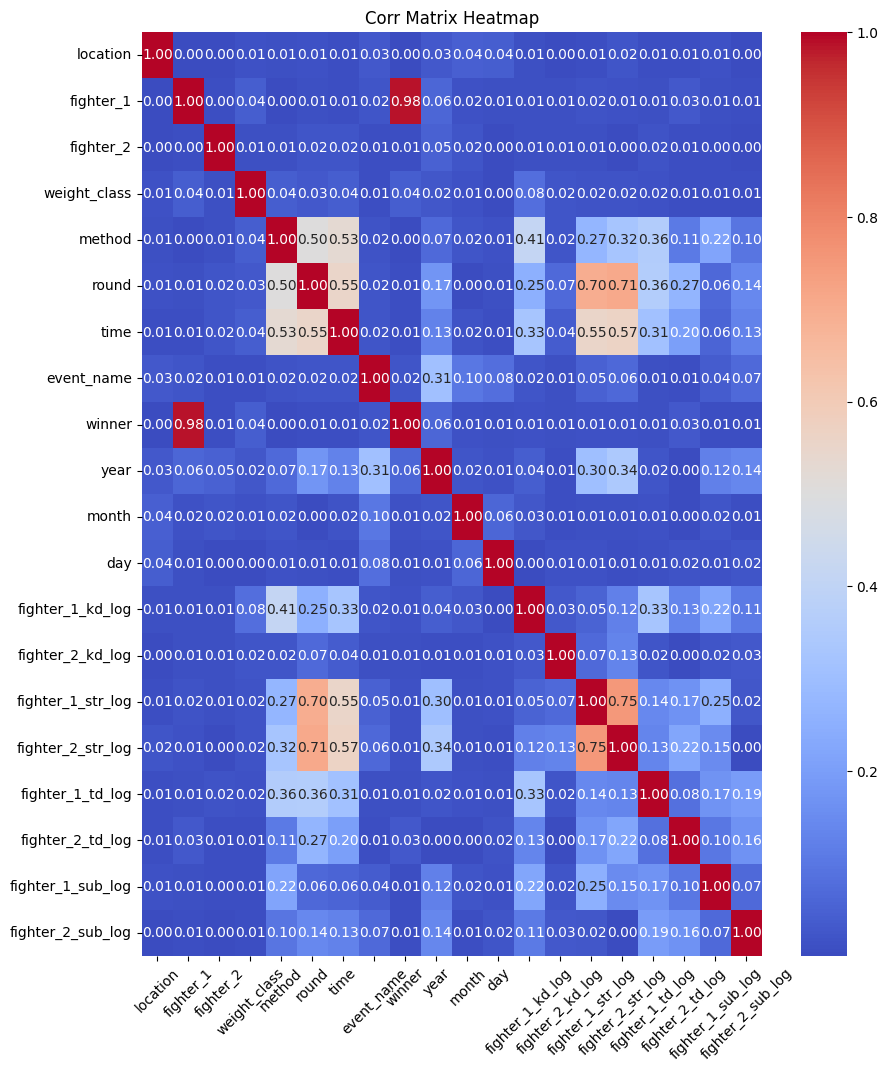

In [25]:
plt.figure(figsize=(10, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.xticks(rotation=45) #rotate x -axis for 45 degree
plt.title('Corr Matrix Heatmap')
plt.show()

In [26]:
# For data analysis, saving joblib file into data_analysis folder
# Saving all predictions using joblib into the data/predictions folder
import os
import joblib

folder_path = os.path.join("data_analysis")

file_path = os.path.join(folder_path, "corr_matrix.joblib")

joblib.dump(corr_matrix, file_path)

['data_analysis/corr_matrix.joblib']

In [27]:
# Visualizing the corr_matrix by Plotly Express
import plotly.express as px

# Create a long-form dataframe for Plotly
corr_long = corr_matrix.reset_index().melt(id_vars='index')
corr_long.columns = ['F-t 1', 'F-t 2', 'Corr']

# Interactive heatmap with Plotly Express
fig = px.imshow(
    corr_matrix,
    text_auto = '.2f',
    aspect = 'auto',
    color_continuous_scale = 'RdBu_r',
    zmin = -1, zmax = 1,
    title = 'Corr Matrix Heatmap (Ineractive)'
)
fig.update_layout(
    width=900,
    height=800,
    xaxis_title= 'Features',
    yaxis_title= 'Features'
)
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [28]:
# Next step is to find the low variances
from sklearn.feature_selection import VarianceThreshold

# Set threshold the variance 
threshold = 0.01

# Initialize variance threshold 
selector = VarianceThreshold(threshold=threshold)

#  Fit on the dataset 
selector.fit(df_filtered)

# Features with low variances
low_features_variances = df_filtered.columns[~selector.get_support()]
print(f'Features with low variances(to drop): ', list(low_features_variances))

# Dop the low variance features
df_low_variance_filtered = df_filtered.drop(columns=low_features_variances)

# Print and compare the orginal shape and low variance features
print(f'\nOriginal shape: ', df_filtered.shape)
print(f'Shape after dropping the low variance features: ', df_low_variance_filtered.shape)

Features with low variances(to drop):  []

Original shape:  (7417, 18)
Shape after dropping the low variance features:  (7417, 18)


In [29]:
df_low_variance_filtered.info(

)

<class 'pandas.DataFrame'>
RangeIndex: 7417 entries, 0 to 7416
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   location           7417 non-null   int16  
 1   fighter_1          7417 non-null   int16  
 2   fighter_2          7417 non-null   int16  
 3   weight_class       7417 non-null   int8   
 4   method             7417 non-null   int8   
 5   round              7417 non-null   float32
 6   time               7417 non-null   int16  
 7   event_name         7417 non-null   int16  
 8   year               7417 non-null   int32  
 9   month              7417 non-null   int32  
 10  day                7417 non-null   int32  
 11  fighter_1_kd_log   7417 non-null   float32
 12  fighter_2_kd_log   7417 non-null   float32
 13  fighter_1_str_log  7417 non-null   float32
 14  fighter_1_td_log   7417 non-null   float32
 15  fighter_2_td_log   7417 non-null   float32
 16  fighter_1_sub_log  7417 non-null   

In [30]:
df = df_low_variance_filtered # change the name to df to catch easily

In [31]:
# Drop uncessary columns(s)
df.drop(['location', 'event_name'], axis=1, inplace=True)
# Model Training process
X = df.drop('method', axis=1)
y = df['method']

In [32]:
# Train and test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
# Linear Regression: Fit the model and make a model intelligent
lr = LinearRegression()
lr.fit(X_train, y_train)
y_lr_pred = lr.predict(X_test)

In [34]:
# Model Evaluation Metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_lr_pred)
mae = mean_absolute_error(y_test, y_lr_pred)
mse = mean_squared_error(y_test, y_lr_pred)
print(f'r2_score: ', r2)
print(f'mea: ', mae)
print(f'mse: ', mse)

r2_score:  0.4468576374108105
mea:  15.474007625578839
mse:  343.67618385448577


In [35]:
# RandomForestRegressor
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
y_rf_pred = rf.predict(X_test)

In [36]:
# Model Evaluation for Random Forest Regressor
r2 = r2_score(y_test, y_rf_pred)
mae = mean_absolute_error(y_test, y_rf_pred)
mse = mean_squared_error(y_test, y_rf_pred)
print(f'r2_score: ', r2)
print(f'mea: ', mae)
print(f'mse: ', mse)

r2_score:  0.6684039497824633
mea:  10.424252021563342
mse:  206.02592176549865


In [37]:
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
y_dt_pred = dt.predict(X_test)

In [38]:
# Model Evaluation for Decision Tree Regressor
r2 = r2_score(y_test, y_dt_pred)
mae = mean_absolute_error(y_test, y_dt_pred)
mse = mean_squared_error(y_test, y_dt_pred)
print(f'r2_score: ', r2)
print(f'mea: ', mae)
print(f'mse: ', mse)

r2_score:  0.37156255505567126
mea:  11.272237196765499
mse:  390.45822102425876


In [39]:
xgb_model = xgb.XGBRegressor(n_estimators=100, 
                         learning_rate=0.1,  # learning interval
                         max_depth=3, 
                         subsample=1, 
                         colsample_bytree=0.8, 
                         random_state=42
                         )
xgb_model.fit(X_train, y_train)
y_pred_xgb_model = xgb_model.predict(X_test)

In [40]:
# Model Evaluation for XGBoost Regressor 
r2 = r2_score(y_test, y_pred_xgb_model)
mae = mean_absolute_error(y_test, y_pred_xgb_model)
mse = mean_squared_error(y_test, y_pred_xgb_model)
print(f'r2_score: ', r2)
print(f'mea: ', mae)
print(f'mse: ', mse)

r2_score:  0.676408052444458
mea:  10.354340553283691
mse:  201.0528564453125


In [41]:
svr = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr.fit(X_train, y_train)
y_svr_pred = svr.predict(X_test)

In [42]:
# Model Evaluation for Support Vector Machine Regressor
r2 = r2_score(y_test, y_svr_pred)
mae = mean_absolute_error(y_test, y_svr_pred)
mse = mean_squared_error(y_test, y_svr_pred)
print(f'r2_score: ', r2)
print(f'mea: ', mae)
print(f'mse: ', mse)

r2_score:  0.15152846957397403
mea:  21.43348570060286
mse:  527.1689123954485


# Using LassoCV (Embedded method) for LinearRegression and SelectRandomModel(Embedded method) for XGBoost.

In [43]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train_scaled, y_train)

,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [44]:
importances = np.abs(lasso.coef_)
selected_features = X_train.columns[importances > 0]

In [45]:
print('Selected features using Lasso (non-zero coefficient): ')
print(selected_features.tolist())

Selected features using Lasso (non-zero coefficient): 
['fighter_1', 'fighter_2', 'round', 'time', 'year', 'month', 'day', 'fighter_1_kd_log', 'fighter_2_kd_log', 'fighter_1_str_log', 'fighter_1_td_log', 'fighter_2_td_log', 'fighter_1_sub_log', 'fighter_2_sub_log']


In [46]:
# Saving only important features 
percentile_threshold = np.percentile(importances, 75) # select top 25 % features
top_features = X_train.columns[importances>=percentile_threshold]

print(f'\nTop 25% features based on Lasso coefficient: ')
print(top_features)



Top 25% features based on Lasso coefficient: 
Index(['round', 'time', 'fighter_1_str_log', 'fighter_1_sub_log'], dtype='str')


In [47]:
X_train_new = X_train[selected_features]
X_test_new = X_test[selected_features]

In [48]:
model_lr = LinearRegression()
model_lr.fit(X_train_new, y_train)
y_pred_model_lr = lasso.predict(X_test_scaled)


In [49]:
# Model Evaluation for Linear Regression using with LassoCV
r2 = r2_score(y_test, y_pred_model_lr)
mae = mean_absolute_error(y_test, y_pred_model_lr)
mse = mean_squared_error(y_test, y_pred_model_lr)
print(f'r2_score: ', r2)
print(f'mea: ', mae)
print(f'mse: ', mse)

r2_score:  0.44361532356722033
mea:  15.3787028358472
mse:  345.6906852269855


In [50]:
# Embedded Method: SelectFromModel
from sklearn.feature_selection import SelectFromModel
from xgboost import XGBRegressor

selector = SelectFromModel(XGBRegressor(
    n_estimators=200, 
    learning_rate=0.01, 
    max_depth=5, 
    subsample=0.9, 
    colsample_bytree=0.9, 
    random_state=42), 
    threshold='median'
    )

# Train data fit + transform
selector.fit(X_train, y_train)
X_train_new = selector.transform(X_train)
X_test_new = selector.transform(X_test)

In [51]:
# XGBoost model 
model = XGBRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=3, 
    subsample=0.9, 
    colsample_bytree=0.9, 
    random_state=42)
model.fit(X_train_new, y_train)
y_model_pred = model.predict(X_test_new)

In [52]:
# Model Evaluation for Linear Regression using with LassoCV
r2 = r2_score(y_test, y_model_pred)
mae = mean_absolute_error(y_test, y_model_pred)
mse = mean_squared_error(y_test, y_model_pred)
print(f'r2_score: ', r2)
print(f'mea: ', mae)
print(f'mse: ', mse)

r2_score:  0.6736276149749756
mea:  10.221091270446777
mse:  202.78038024902344


In [53]:
# Saving all predictions using joblib into the data/predictions folder
import os
import joblib

folder_path = os.path.join("data", "predictions")

file_path = os.path.join(folder_path, "xgb_model.joblib")

joblib.dump(y_model_pred, file_path)

['data/predictions/xgb_model.joblib']

In [55]:
# Finding the best model, using tabulate + function 
from tabulate import tabulate

results = [
    ['Linear Regression with LassoCV', 0.47, 10.22, 202.78],
    ['Random Forest Regressor', 0.66, 10.30, 205.03],
    ['SVR', 0.15, 21.43, 527.16],
    ['Decision Tree Regressor',0.37, 11.26, 390.85 ],
    ['XGBRegressor with Embedded Method',0.67, 11.22, 202.78 ]
]
headers = ['Models', 'r2_score', 'mae', 'mse']
table = tabulate(results, headers=headers, tablefmt='grid', floatfmt='.2f')
print('Log transformation and feature selection did not have a significant impact on the results: ')
print(table)

Log transformation and feature selection did not have a significant impact on the results: 
+-----------------------------------+------------+-------+--------+
| Models                            |   r2_score |   mae |    mse |
+===================================+============+=======+========+
| Linear Regression with LassoCV    |       0.47 | 10.22 | 202.78 |
+-----------------------------------+------------+-------+--------+
| Random Forest Regressor           |       0.66 | 10.30 | 205.03 |
+-----------------------------------+------------+-------+--------+
| SVR                               |       0.15 | 21.43 | 527.16 |
+-----------------------------------+------------+-------+--------+
| Decision Tree Regressor           |       0.37 | 11.26 | 390.85 |
+-----------------------------------+------------+-------+--------+
| XGBRegressor with Embedded Method |       0.67 | 11.22 | 202.78 |
+-----------------------------------+------------+-------+--------+


In [56]:
# Finding the best classifier and best regressor algorithm

best_score = max(model[1] for model in results)  # this takes the maximum values
best_models = []  # we will store the best models here

for model in results:
    # if model[1] equals the best score and model name matches
    if model[1] == best_score and model[0] in ['Random Forest Regressor', 'XGBRegressor with Embedded Method']:
        # append to best_models list
        best_models.append(model)

for model in best_models:
    print(f'Best model: {model[0]}, best R2 score is: {model[1]} which is 67%')

Best model: XGBRegressor with Embedded Method, best R2 score is: 0.67 which is 67%


In [57]:
# Saving the best model 
import os 
import joblib

folder_path = os.path.join("model")

file_path = os.path.join(folder_path, "xgb_best_model.joblib")

joblib.dump(y_model_pred, file_path)

['model/xgb_best_model.joblib']